In [1]:
import socket
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import psutil
import os
import time
import struct
import sys

In [2]:
# 799.305 MHz

In [2]:
UDP_IP = "192.168.3.40"

UDP_PORT = 4096 

In [3]:
sock = socket.socket(socket.AF_INET, # Internet

           socket.SOCK_DGRAM) # UDP

sock.bind((UDP_IP, UDP_PORT)) 

In [4]:
def capturePacket(byteshift=-1):
    """
    Q - Remove byte rolling and conversion to separate function?
    """

    data = sock.recv(9000) # buffer size is 1024 bytes

    data = bytearray(data)

    data = np.roll(data,byteshift)

    return np.frombuffer(data, dtype="<i").astype("float")

def getNpackets(N,byteshift=-1):
    
    return np.array([capturePacket(byteshift) for p in range(N)])


In [ ]:
packetrate = 512e6/2**20 # packets/sec
Nsec = 1
p=getNpackets(int(packetrate*Nsec))

In [25]:
#np.save('/home/rfsoc/rfsoc_result/Steve/230214/20230214_timestream_100mK_grid_notrotating.npy',p)

#np.save('/home/rfsoc/rfsoc_result/20230331_timestream_23dB_RFsoc1_handwaving.npy',p)

#np.save('nrc_230419_on_res_10sec_bump.npy',p)

In [27]:
I, Q = p[:,16::2].T, p[:,17::2].T

<IPython.core.display.Javascript object>


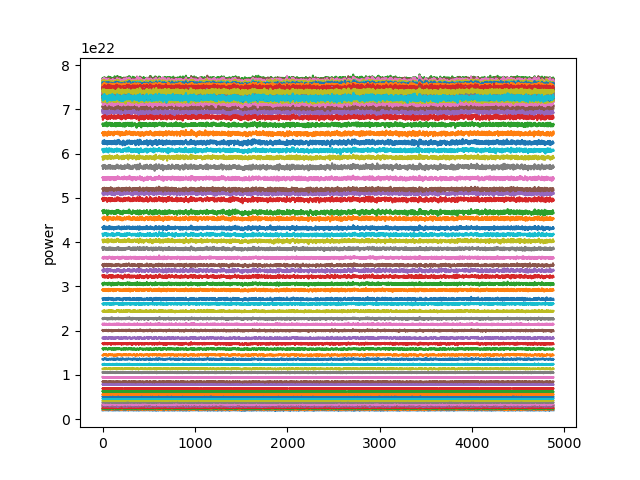

Text(0, 0.5, 'power')

In [28]:
%matplotlib notebook
for i in range(0,100):
    plt.plot(np.abs(I[i]**2 + Q[i]**2)**2)
plt.ylabel('power')

<IPython.core.display.Javascript object>


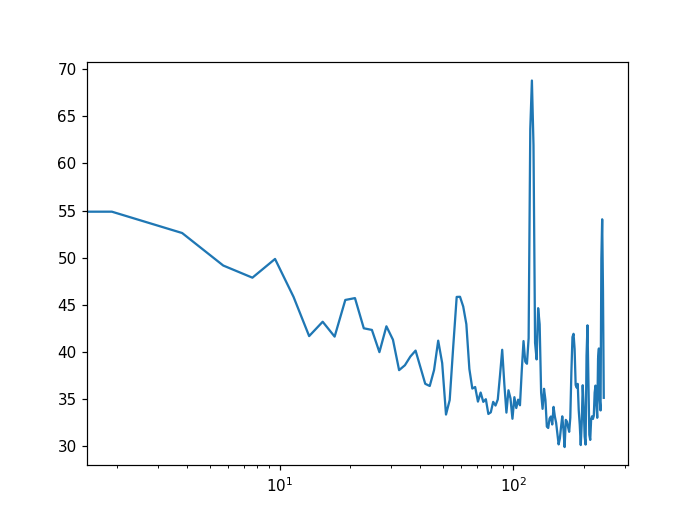

In [43]:
ch = 300
from scipy import signal
f, S = signal.welch( I[ch], fs = 512e6/2**20)
plt.figure()
plt.semilogx(f,10.*np.log10(S))